# Oppgave 1f)

In [14]:
# FRA FORRIGE OPPGAVE, TRENGER IKKE Å KOPIERES INN I MAIN

import numpy as np
import matplotlib.pyplot as plt


def RungeKutta_32(x_init, x_end, y_init, f, alpha, h_0, tol):
    n = 0                           # Teller antall steg som aksepteres
    n_total = 0                     # Teller antall steg som testes
    h_n = h_0                       # Steglengde ved steg n
    x_n = x_init                    # x-verdi ved steg n
    y_n = y_init                    # y-vektor ved steg n
    
    x_array = [x_n]                 # Liste til x-verdier for hvert steg
    y_matrix = [y_n]                # 2D-liste med y-vektor for hvert steg 
    step_array = []                 # Liste til steglengde for hvert steg


    k_1 = f(x_init, y_init)

    while (x_end - x_n) > 0:
        h_n = min(h_n, x_end - x_n)
        k_2 = f(x_n + (1/2)*h_n, y_n + (1/2)*h_n*k_1)
        k_3 = f(x_n + (3/4)*h_n, y_n + (3/4)*h_n*k_2)

        y_next = y_n + (1/9)*h_n*(2*k_1 + 3*k_2 + 4*k_3)                # Midlertig oppdatering av y
        x_next = x_n + h_n                                              # Oppdatering av x

        k_4 = f(x_next, y_next)
        z_next = y_n + (1/24)*h_n*(7*k_1 + 6*k_2 + 8*k_3 + 3*k_4)       # Beregner alternativ y for sammenligning

        est = abs(y_next[0] - z_next[0])
        if est < tol:                                                   # Sjekker om skrittet aksepteres
            n += 1                                                      # Oppdaterer antall skritt
            k_1 = k_4                                                   # Oppdaterer k_1
            
            x_array.append(x_next)                                      # Legger til x-verdi i listen siden skrittet aksepteres
            y_matrix.append(y_next)                                     # Legger til y-vektor i listen siden skrittet aksepteres
            step_array.append(h_n)                                      # Legger til steglengde i listen siden skrittet aksepteres
            
            x_n = x_next                                                # Oppdaterer x-verdi siden skrittet aksepteres
            y_n = y_next                                                # Oppdaterer y-vektor siden skrittet aksepteres

        h_new = alpha*h_n*(tol/est)**(1/3)                              # Beregner ny steglengde  
        h_n = h_new                                                     # Oppdaterer steglengden

        n_total += 1                                                    # Oppdaterer antall testede skritt



    return np.array(x_array), np.array(y_matrix), np.array(step_array), n, n_total

In [15]:
# Rotfunksjonen:

def rootFinder(g, z0, z1, tol, max_iter = 100): 
    b_values = []

    for i in range(max_iter): 
        g_z0, g_z1 = g(z0), g(z1)
        
        if abs(g_z1 - g_z0) < tol:                                 # Unngår divisjon med null      
            print("små forskjeller i funksjonsverdiene gjør ")
            break 

        z2 = z1 - g_z1*(z1 - z0)/(g_z1 - g_z0)
        b_values.append(z2)

        # Sjekker konvergens: 
        if abs(z2 - z1) < tol: 
            return z2, b_values

        # Oppdaterer gjettene: 
        z0, z1 = z1, z2 
    raise ValueError("")

In [20]:
def solveBVproblem(x_init, x_end, f, z0, z1, alpha, h_0, tol):    # Definerer funksjon for å løse randverdiproblem
    yb_values = []                                                # Liste for å lagre alle testede løsninger

    def g(b):                                                     # Definerer funksjonen for siste grensebetingelse, gitt b
        y_init = np.array([0, b])                           
        x_values, y_matrix, step_array, n, n_total = RungeKutta_32(x_init, x_end, y_init, f, alpha, h_0, tol) # Løser IVP for gitt b
        y_end = y_matrix[-1, 0]                                   # Henter siste y-verdi                                              
    
        return y_end


    b, b_values = rootFinder(g, z0, z1, tol, max_iter=100)        # Finner b som gir oppfylt grensebetingelse og testede b'er

    for value in b_values:
        y_init = np.array([0, value])
        x_values, y_matrix, step_array, n, n_total = RungeKutta_32(x_init, x_end, y_init, f, alpha, h_0, tol) # Løser IVP for riktig b   
        yb_values.append(y_matrix[:, 0])                           # Henter y-verdier for gitt b

    return x_values, yb_values, b_values


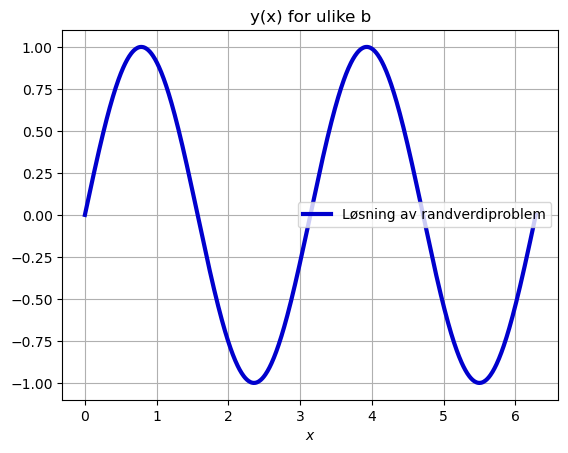

In [24]:
# Løser randverdiproblem
import matplotlib.cm as cm

alpha = 0.8
h_0 = 0.01
tol = 10**(-7)

x_init, x_end = 0, 2*np.pi
z0, z1 = 0, 1

def f_array(x, y_array):                                                   # Definerer f som returnerer vektor
    f = -4*np.sin(2*x)                                                    
    f_array = np.array([y_array[1], f])
    return f_array


x_values, yb_values, b_values = solveBVproblem(x_init, x_end, f_array, z0, z1, alpha, h_0, tol)


iteration_num = len(yb_values)
colors = ["plum", "mediumorchid", "blueviolet", "darkslateblue", "royalblue"]

for i in range(iteration_num - 1):                                         
    plt.plot(x_values, yb_values[i], color = colors[i])

plt.plot(x_values, yb_values[-1], label = "Løsning av randverdiproblem", color = "mediumblue", linewidth = 3)
plt.xlabel("$x$")
plt.title("y(x) for ulike b")
plt.grid()
plt.legend()
plt.show()

## g)

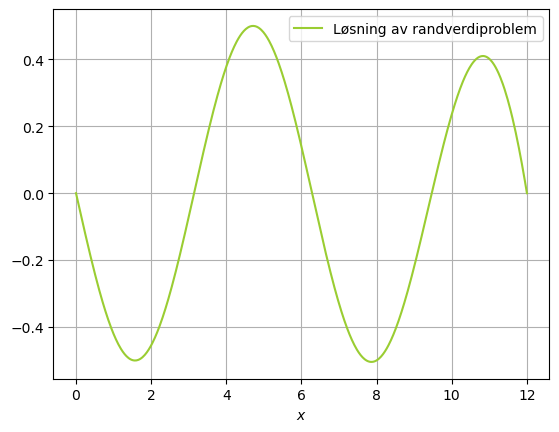

In [10]:
def g_array(x, y_array):
    g_array = np.array([y_array[1], y_array[0] + np.sin(x)])
    return g_array


alpha = 0.8
h_0 = 0.01
tol = 10**(-7)

x_init, x_end = 0, 12
z0, z1 = 0, 1

x_values, y_values, yb_values, n = solveBVproblem(x_init, x_end, g_array, z0, z1, alpha, h_0, tol)

plt.plot(x_values, y_values, label = "Løsning av randverdiproblem", color = "yellowgreen")
plt.xlabel("$x$")
plt.grid()
plt.legend()
plt.show()